# Lab 04: Simple Linear Regression

In the following lab we will explore the linear regression model. More specifically, the case of Simple Linear Regression
where our data consists of a single explanatory variable:
$S=\left\{\left(\mathbf{x}_i, y_i\right)\right\}^m_{i=1} \quad s.t. \quad \mathbf{x}_i,y_i\in\mathbb{R}$


As we have only a single explanatory variable, fitting a linear regression model means fitting a line: 
$y_i=w_1\cdot x_i + w_0$. We begin with creating such a sample $$S$$ where $x_i \in \left[0,100\right]$ and $w_0=1, w_1=2$.

In [1]:
import numpy as np
w0, w1 = 1, 2

x = np.linspace(0, 100, 20)
y = w1*x + w0

print("x:", x)
print("y:", y)

x: [  0.           5.26315789  10.52631579  15.78947368  21.05263158
  26.31578947  31.57894737  36.84210526  42.10526316  47.36842105
  52.63157895  57.89473684  63.15789474  68.42105263  73.68421053
  78.94736842  84.21052632  89.47368421  94.73684211 100.        ]
y: [  1.          11.52631579  22.05263158  32.57894737  43.10526316
  53.63157895  64.15789474  74.68421053  85.21052632  95.73684211
 106.26315789 116.78947368 127.31578947 137.84210526 148.36842105
 158.89473684 169.42105263 179.94736842 190.47368421 201.        ]


Next, we visualize the data using a simple scatter plot:

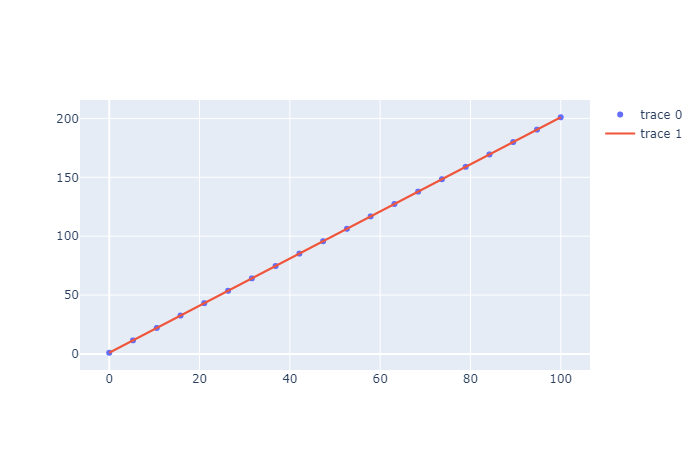

In [2]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "png"

f = go.Figure([
    go.Scatter(x=x, y=y, mode="markers"),
    go.Scatter(x=x, y=y)
])
    
f.show()

Using this sample as a training set, let us compute the Ordinary Least Squares (OLS) estimators $\widehat{w_0},\widehat{w_1}$ of model.
Try and think what would you expect the output to be?

In [3]:
from sklearn import linear_model
model = linear_model.LinearRegression()

model.fit(x.reshape((-1,1)), y)
print("Estimated intercept:", model.intercept_)
print("Estimated coefficient:", model.coef_[0])

Estimated intercept: 0.9999999999999716
Estimated coefficient: 2.0000000000000004


As the given datasets used to fit the model lays exactly on a line, the estimated coefficients are the correct ones. 
Next, let us add some Gaussian noise to the data and see how it influences our estimation. So:  
$\forall i \in \left[ m \right]\quad y_i=w_1\cdot x_i + w_0 + \varepsilon_i \quad s.t.\quad \varepsilon\sim\mathcal{N}\left(0,\sigma^2I_m\right)$

Namely, the noise of each sample distributes by a Gaussian with zero mean and $\sigma^2$ variance, and is uncorrelated between samples.

*Notice that from now on we mark the $y$'s generated by the noise-less model with `y_`. This is so it is clear that the "real"
$y$s observed in a given sample are noisy.*

In [4]:
if "y_" not in locals(): y_ = y
epsilon = np.random.normal(loc=0, scale=20, size=len(x))
y = y_ + epsilon




Clearly, once we add the noise to $y$ 